In [1]:
!pip install -q kaggle

import os
import shutil
import zipfile
import random

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf

from PIL import Image

from tensorflow.keras import layers, models
from tensorflow.keras.optimizers import Adam

from sklearn.metrics import (confusion_matrix,classification_report,accuracy_score,precision_score,recall_score,f1_score,roc_curve,roc_auc_score)

print("TensorFlow version:", tf.__version__)
print("GPU:", tf.config.list_physical_devices('GPU'))

TensorFlow version: 2.20.0
GPU: []


In [2]:
!pip install -q -U kaggle

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 126.2/126.2 kB 3.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 262.5/262.5 kB 11.3 MB/s eta 0:00:00


In [3]:
import os

os.environ["KAGGLE_API_TOKEN"] = "KGAT_f01e7195f0f0ac2a719af09ac41d2f18"

print("Kaggle API token configured.")

Kaggle API token configured.


In [4]:
!kaggle datasets list -s chest-xray-pneumonia

ref                                                             title                                                      size  lastUpdated                 downloadCount  voteCount  usabilityRating  
--------------------------------------------------------------  --------------------------------------------------  -----------  --------------------------  -------------  ---------  ---------------  
divyam6969/chest-xray-pneumonia-dataset                         Chest XRAY - Pneumonia Dataset                       1151535496  2024-01-17 12:19:16.570000           1465         30  0.6875           
kostasdiamantaras/chest-xrays-bacterial-viral-pneumonia-normal  Chest Xrays: bacterial / viral pneumonia / normal    1222999548  2020-10-27 16:51:15.783000           2319         22  0.7058824        
amanullahasraf/covid19-pneumonia-normal-chest-xray-pa-dataset   COVID19_Pneumonia_Normal_Chest_Xray_PA_Dataset       2053474983  2020-07-13 05:54:22.483000           4337         35  0.8125       

In [5]:
!kaggle datasets download -d paultimothymooney/chest-xray-pneumonia

Dataset URL: https://www.kaggle.com/datasets/paultimothymooney/chest-xray-pneumonia
License(s): other
100% 2.29G/2.29G [00:27<00:00, 89.8MB/s]



In [6]:
import zipfile
import os

zip_path = "/content/chest-xray-pneumonia.zip"
extract_path = "/content/pneumonia_dataset"

os.makedirs(extract_path, exist_ok=True)

with zipfile.ZipFile(zip_path, "r") as zip_ref:
    zip_ref.extractall(extract_path)

print("Dataset extracted successfully.")

Dataset extracted successfully.


In [7]:
!find /content/pneumonia_dataset -maxdepth 3 -type d

/content/pneumonia_dataset
/content/pneumonia_dataset/chest_xray
/content/pneumonia_dataset/chest_xray/test
/content/pneumonia_dataset/chest_xray/test/NORMAL
/content/pneumonia_dataset/chest_xray/test/PNEUMONIA
/content/pneumonia_dataset/chest_xray/train
/content/pneumonia_dataset/chest_xray/train/NORMAL
/content/pneumonia_dataset/chest_xray/train/PNEUMONIA
/content/pneumonia_dataset/chest_xray/__MACOSX
/content/pneumonia_dataset/chest_xray/__MACOSX/chest_xray
/content/pneumonia_dataset/chest_xray/chest_xray
/content/pneumonia_dataset/chest_xray/chest_xray/test
/content/pneumonia_dataset/chest_xray/chest_xray/train
/content/pneumonia_dataset/chest_xray/chest_xray/val
/content/pneumonia_dataset/chest_xray/val
/content/pneumonia_dataset/chest_xray/val/NORMAL
/content/pneumonia_dataset/chest_xray/val/PNEUMONIA


In [8]:
DATASET_PATH = "/content/pneumonia_dataset/chest_xray"

TRAIN_DIR = os.path.join(DATASET_PATH, "train")
VAL_DIR   = os.path.join(DATASET_PATH, "val")
TEST_DIR  = os.path.join(DATASET_PATH, "test")

In [9]:
import os

DATASET_PATH = "/content/pneumonia_dataset/chest_xray"

TRAIN_DIR = os.path.join(DATASET_PATH, "train")
VAL_DIR   = os.path.join(DATASET_PATH, "val")
TEST_DIR  = os.path.join(DATASET_PATH, "test")

print("Train path:", TRAIN_DIR)
print("Validation path:", VAL_DIR)
print("Test path:", TEST_DIR)

Train path: /content/pneumonia_dataset/chest_xray/train
Validation path: /content/pneumonia_dataset/chest_xray/val
Test path: /content/pneumonia_dataset/chest_xray/test


In [10]:
print("Train exists:", os.path.exists(TRAIN_DIR))
print("Validation exists:", os.path.exists(VAL_DIR))
print("Test exists:", os.path.exists(TEST_DIR))

print("\nTrain folders:", os.listdir(TRAIN_DIR))
print("Validation folders:", os.listdir(VAL_DIR))
print("Test folders:", os.listdir(TEST_DIR))

Train exists: True
Validation exists: True
Test exists: True

Train folders: ['NORMAL', 'PNEUMONIA']
Validation folders: ['NORMAL', 'PNEUMONIA']
Test folders: ['NORMAL', 'PNEUMONIA']


In [11]:
def count_images(folder):

    normal_folder = os.path.join(folder, "NORMAL")
    pneumonia_folder = os.path.join(folder, "PNEUMONIA")

    normal_count = len([
        f for f in os.listdir(normal_folder)
        if f.lower().endswith((".jpg", ".jpeg", ".png"))
    ])

    pneumonia_count = len([
        f for f in os.listdir(pneumonia_folder)
        if f.lower().endswith((".jpg", ".jpeg", ".png"))
    ])

    return normal_count, pneumonia_count


train_normal, train_pneumonia = count_images(TRAIN_DIR)
val_normal, val_pneumonia = count_images(VAL_DIR)
test_normal, test_pneumonia = count_images(TEST_DIR)


print("-------- DATASET --------")

print("\nTRAIN")
print("NORMAL   :", train_normal)
print("PNEUMONIA:", train_pneumonia)
print("TOTAL    :", train_normal + train_pneumonia)

print("\nVALIDATION")
print("NORMAL   :", val_normal)
print("PNEUMONIA:", val_pneumonia)
print("TOTAL    :", val_normal + val_pneumonia)

print("\nTEST")
print("NORMAL   :", test_normal)
print("PNEUMONIA:", test_pneumonia)
print("TOTAL    :", test_normal + test_pneumonia)

-------- DATASET --------

TRAIN
NORMAL   : 1341
PNEUMONIA: 3875
TOTAL    : 5216

VALIDATION
NORMAL   : 8
PNEUMONIA: 8
TOTAL    : 16

TEST
NORMAL   : 234
PNEUMONIA: 390
TOTAL    : 624


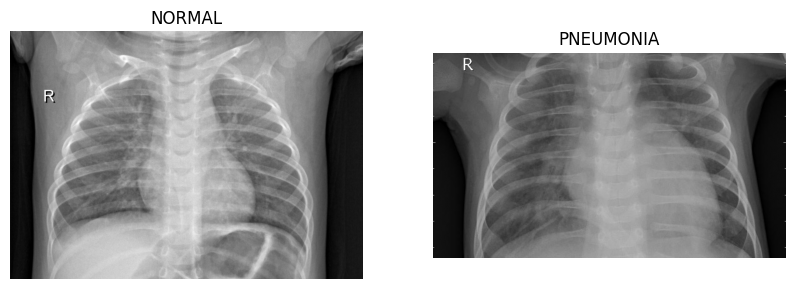

In [12]:
import random
from PIL import Image
import matplotlib.pyplot as plt

def get_random_image(folder):

    images = [
        f for f in os.listdir(folder)
        if f.lower().endswith((".jpg", ".jpeg", ".png"))
    ]

    return os.path.join(
        folder,
        random.choice(images)
    )


normal_path = get_random_image(
    os.path.join(TRAIN_DIR, "NORMAL")
)

pneumonia_path = get_random_image(
    os.path.join(TRAIN_DIR, "PNEUMONIA")
)


normal_image = Image.open(normal_path)
pneumonia_image = Image.open(pneumonia_path)


plt.figure(figsize=(10, 5))

plt.subplot(1, 2, 1)
plt.imshow(normal_image, cmap="gray")
plt.title("NORMAL")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(pneumonia_image, cmap="gray")
plt.title("PNEUMONIA")
plt.axis("off")

plt.show()

In [13]:
IMG_SIZE = (128, 128)
BATCH_SIZE = 32
EPOCHS = 15

LEARNING_RATE = 0.001
DROPOUT_RATE = 0.50

SEED = 42

In [14]:
import tensorflow as tf
from tensorflow.keras import layers

train_ds = tf.keras.utils.image_dataset_from_directory(

    TRAIN_DIR,

    labels="inferred",

    label_mode="binary",

    color_mode="grayscale",

    image_size=IMG_SIZE,

    batch_size=BATCH_SIZE,

    shuffle=True,

    seed=SEED
)


val_ds = tf.keras.utils.image_dataset_from_directory(

    VAL_DIR,

    labels="inferred",

    label_mode="binary",

    color_mode="grayscale",

    image_size=IMG_SIZE,

    batch_size=BATCH_SIZE,

    shuffle=False
)


test_ds = tf.keras.utils.image_dataset_from_directory(

    TEST_DIR,

    labels="inferred",

    label_mode="binary",

    color_mode="grayscale",

    image_size=IMG_SIZE,

    batch_size=BATCH_SIZE,

    shuffle=False
)

Found 5216 files belonging to 2 classes.
Found 16 files belonging to 2 classes.
Found 624 files belonging to 2 classes.


In [15]:
print("Classes:", train_ds.class_names)

Classes: ['NORMAL', 'PNEUMONIA']


In [16]:
normalization_layer = layers.Rescaling(1./255)

train_ds = train_ds.map(
    lambda x, y: (normalization_layer(x), y)
)

val_ds = val_ds.map(
    lambda x, y: (normalization_layer(x), y)
)

test_ds = test_ds.map(
    lambda x, y: (normalization_layer(x), y)
)

In [17]:
AUTOTUNE = tf.data.AUTOTUNE

train_ds = train_ds.prefetch(AUTOTUNE)
val_ds = val_ds.prefetch(AUTOTUNE)
test_ds = test_ds.prefetch(AUTOTUNE)

In [18]:
for images, labels in train_ds.take(1):

    print("Image shape:", images.shape)
    print("Label shape:", labels.shape)

    print(
        "Minimum pixel:",
        tf.reduce_min(images).numpy()
    )

    print(
        "Maximum pixel:",
        tf.reduce_max(images).numpy()
    )

Image shape: (32, 128, 128, 1)
Label shape: (32, 1)
Minimum pixel: 0.0
Maximum pixel: 1.0


In [19]:
from tensorflow.keras import models
from tensorflow.keras.optimizers import Adam


def create_cnn(
    dropout_rate=0.50,
    learning_rate=0.001
):

    model = models.Sequential([

        layers.Input(
            shape=(128, 128, 1)
        ),

        layers.Conv2D(
            32,
            (3, 3),
            activation="relu"
        ),

        layers.MaxPooling2D(
            (2, 2)
        ),

        layers.Conv2D(
            64,
            (3, 3),
            activation="relu"
        ),

        layers.MaxPooling2D(
            (2, 2)
        ),

        layers.Conv2D(
            128,
            (3, 3),
            activation="relu"
        ),

        layers.MaxPooling2D(
            (2, 2)
        ),

        layers.Flatten(),

        layers.Dense(
            128,
            activation="relu"
        ),

        layers.Dropout(
            dropout_rate
        ),

        layers.Dense(
            1,
            activation="sigmoid"
        )
    ])


    optimizer = Adam(
        learning_rate=learning_rate
    )


    model.compile(

        optimizer=optimizer,

        loss="binary_crossentropy",

        metrics=["accuracy"]
    )


    return model

In [20]:
baseline_model = create_cnn(
    dropout_rate=0.50,
    learning_rate=0.001
)

baseline_model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 126, 126, 32)   │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 63, 63, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 61, 61, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 30, 30, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 28, 28, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 14, 14, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 25088)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │     3,211,392 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,304,193 (12.60 MB)

 Trainable params: 3,304,193 (12.60 MB)

 Non-trainable params: 0 (0.00 B)

In [21]:
history = baseline_model.fit(

    train_ds,

    validation_data=val_ds,

    epochs=15
)

Epoch 1/15
163/163 ━━━━━━━━━━━━━━━━━━━━ 201s 1s/step - accuracy: 0.8836 - loss: 0.2771 - val_accuracy: 0.9375 - val_loss: 0.2235
Epoch 2/15
163/163 ━━━━━━━━━━━━━━━━━━━━ 196s 1s/step - accuracy: 0.9578 - loss: 0.1182 - val_accuracy: 0.8125 - val_loss: 0.3551
Epoch 3/15
163/163 ━━━━━━━━━━━━━━━━━━━━ 212s 1s/step - accuracy: 0.9651 - loss: 0.0970 - val_accuracy: 1.0000 - val_loss: 0.1908
Epoch 4/15
163/163 ━━━━━━━━━━━━━━━━━━━━ 196s 1s/step - accuracy: 0.9707 - loss: 0.0806 - val_accuracy: 1.0000 - val_loss: 0.0790
Epoch 5/15
163/163 ━━━━━━━━━━━━━━━━━━━━ 201s 1s/step - accuracy: 0.9718 - loss: 0.0698 - val_accuracy: 1.0000 - val_loss: 0.0915
Epoch 6/15
163/163 ━━━━━━━━━━━━━━━━━━━━ 211s 1s/step - accuracy: 0.9787 - loss: 0.0573 - val_accuracy: 1.0000 - val_loss: 0.0800
Epoch 7/15
163/163 ━━━━━━━━━━━━━━━━━━━━ 194s 1s/step - accuracy: 0.9816 - loss: 0.0541 - val_accuracy: 0.6875 - val_loss: 0.4795
Epoch 8/15
163/163 ━━━━━━━━━━━━━━━━━━━━ 194s 1s/step - accuracy: 0.9818 - loss: 0.0500 - val_accu

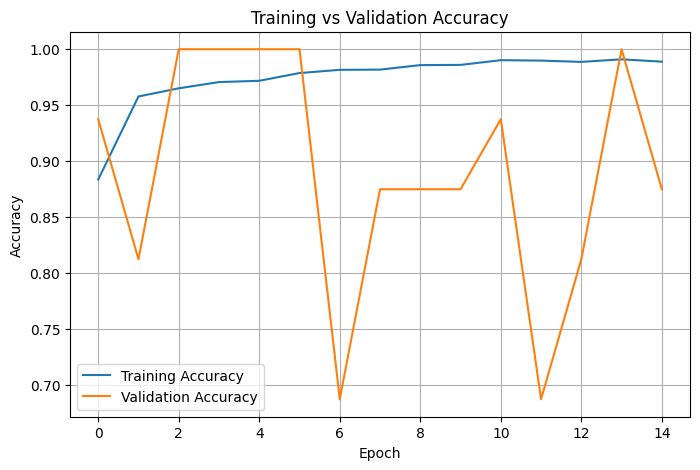

In [22]:
plt.figure(figsize=(8, 5))

plt.plot(
    history.history["accuracy"],
    label="Training Accuracy"
)

plt.plot(
    history.history["val_accuracy"],
    label="Validation Accuracy"
)

plt.xlabel("Epoch")
plt.ylabel("Accuracy")

plt.title(
    "Training vs Validation Accuracy"
)

plt.legend()
plt.grid(True)

plt.show()

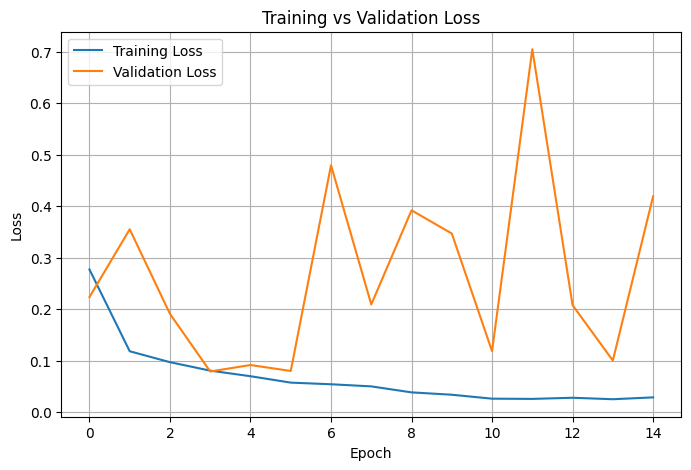

In [23]:
plt.figure(figsize=(8, 5))

plt.plot(
    history.history["loss"],
    label="Training Loss"
)

plt.plot(
    history.history["val_loss"],
    label="Validation Loss"
)

plt.xlabel("Epoch")
plt.ylabel("Loss")

plt.title(
    "Training vs Validation Loss"
)

plt.legend()
plt.grid(True)

plt.show()

In [24]:
test_loss, test_accuracy = baseline_model.evaluate(
    test_ds
)

print("Test Loss:", test_loss)
print("Test Accuracy:", test_accuracy)

20/20 ━━━━━━━━━━━━━━━━━━━━ 8s 358ms/step - accuracy: 0.7468 - loss: 2.1518
Test Loss: 2.151766300201416
Test Accuracy: 0.7467948794364929


In [25]:
y_true = []
y_probability = []


for images, labels in test_ds:

    predictions = baseline_model.predict(
        images,
        verbose=0
    )

    y_true.extend(
        labels.numpy().flatten()
    )

    y_probability.extend(
        predictions.flatten()
    )


y_true = np.array(y_true)
y_probability = np.array(y_probability)


y_pred = (
    y_probability >= 0.5
).astype(int)

In [26]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)


accuracy = accuracy_score(
    y_true,
    y_pred
)

precision = precision_score(
    y_true,
    y_pred,
    zero_division=0
)

recall = recall_score(
    y_true,
    y_pred,
    zero_division=0
)

f1 = f1_score(
    y_true,
    y_pred,
    zero_division=0
)


print("--------------------------------")
print("BASELINE RESULTS")
print("--------------------------------")

print("Accuracy :", accuracy)
print("Precision:", precision)
print("Recall   :", recall)
print("F1 Score :", f1)

--------------------------------
BASELINE RESULTS
--------------------------------
Accuracy : 0.7467948717948718
Precision: 0.7132352941176471
Recall   : 0.9948717948717949
F1 Score : 0.8308351177730193


In [27]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(
    y_true,
    y_pred
)

print(cm)

[[ 78 156]
 [  2 388]]


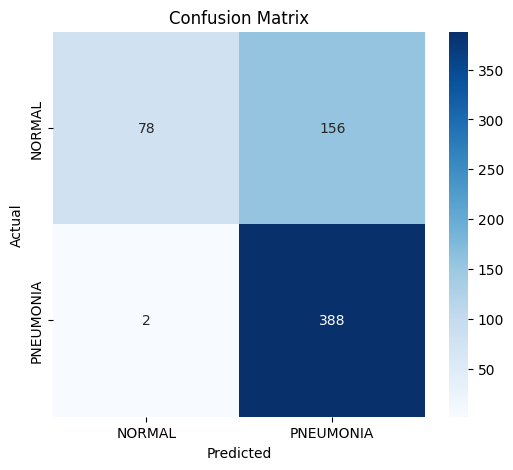

In [28]:
plt.figure(figsize=(6, 5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=[
        "NORMAL",
        "PNEUMONIA"
    ],
    yticklabels=[
        "NORMAL",
        "PNEUMONIA"
    ]
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")

plt.show()

In [29]:
print(
    classification_report(
        y_true,
        y_pred,
        target_names=[
            "NORMAL",
            "PNEUMONIA"
        ],
        zero_division=0
    )
)

              precision    recall  f1-score   support

      NORMAL       0.97      0.33      0.50       234
   PNEUMONIA       0.71      0.99      0.83       390

    accuracy                           0.75       624
   macro avg       0.84      0.66      0.66       624
weighted avg       0.81      0.75      0.71       624



In [30]:
print("Baseline")
print("-------------------------")

print(
    "Learning Rate:",
    0.001
)

print(
    "Batch Size:",
    32
)

print(
    "Dropout:",
    0.50
)

print(
    "Epochs:",
    15
)

print(
    "Train Accuracy:",
    history.history["accuracy"][-1]
)

print(
    "Validation Accuracy:",
    history.history["val_accuracy"][-1]
)

print(
    "Test Accuracy:",
    test_accuracy
)

print(
    "Precision:",
    precision
)

print(
    "Recall:",
    recall
)

print(
    "F1 Score:",
    f1
)

Baseline
-------------------------
Learning Rate: 0.001
Batch Size: 32
Dropout: 0.5
Epochs: 15
Train Accuracy: 0.9888803958892822
Validation Accuracy: 0.875
Test Accuracy: 0.7467948794364929
Precision: 0.7132352941176471
Recall: 0.9948717948717949
F1 Score: 0.8308351177730193
